# A tour of the pipeline

This notebook walks through the project in the order of Chapter 13 of the reference book (Géron, *Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow*, 2019): the Data API on sharded CSV files, the TFRecord format, the Features API (here with Keras 3 layers) and TensorFlow Datasets. Each step uses the project's own code from `src/tfdata_mlops`, so what you see here is what the Prefect flows run.

It uses the quick configuration, so it finishes in a few minutes. The measured results of the full experiment are in `reports/RESULTS.md`.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from tfdata_mlops import data
from tfdata_mlops import features as F
from tfdata_mlops import tfrecord as tfr
from tfdata_mlops.config import load_config
from tfdata_mlops.csv_pipeline import csv_reader_dataset
from tfdata_mlops.modeling import df_to_features
from tfdata_mlops.prepare import prepare_data

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.20.0 | Keras 3.15.1


## 1. The data and its shards

The data is the California housing table of Chapter 2 (20,640 block groups, one missing-value column, one text column). It is split 60 / 20 / 20 with a split stratified on income, the statistics (medians, means, standard deviations) are learned from the training rows only, and each split is written as several shard files in three formats: CSV, TFRecord and GZIP-compressed TFRecord.

In [2]:
cfg = load_config("configs/quick_flow_config.yaml")
cfg["data"]["work_dir"] = "data/notebook_work"
prep = prepare_data(cfg["data"], cfg["seed"])

print("rows:", {name: len(prep.table(name)) for name in ("train", "valid", "test")})
print("shards:", prep.shard_counts)
print("missing total_bedrooms in training:", int(prep.split.train.total_bedrooms.isna().sum()))
prep.split.train.head()

rows: {'train': 12384, 'valid': 4128, 'test': 4128}
shards: {'train': 20, 'valid': 10, 'test': 10}
missing total_bedrooms in training: 124


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-123.84,39.46,47.0,1150.0,244.0,552.0,201.0,2.5192,<1H OCEAN,110400.0
1,-118.04,34.06,30.0,2019.0,551.0,2481.0,484.0,3.1875,<1H OCEAN,154200.0
2,-119.30,34.27,17.0,1527.0,503.0,688.0,423.0,1.6007,NEAR OCEAN,187500.0
3,-119.53,37.34,26.0,4047.0,702.0,571.0,199.0,2.3482,INLAND,179500.0
4,-117.83,33.80,30.0,4713.0,758.0,2271.0,730.0,5.8622,<1H OCEAN,221000.0


In [3]:
first = Path(prep.csv["train"][0])
print(first.name)
print("\n".join(first.read_text().splitlines()[:3]))

train_00.csv
longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
-123.84,39.46,47.0,1150.0,244.0,552.0,201.0,2.5192,<1H OCEAN,110400.0
-118.04,34.06,30.0,2019.0,551.0,2481.0,484.0,3.1875,<1H OCEAN,154200.0


## 2. The Data API on sharded CSV files

`csv_reader_dataset` is the book's function with its knobs exposed. The default settings are the book's: five files read at once with their lines interleaved, a shuffling buffer, parsing and standardising with five threads, batching, and prefetching. Missing numbers are replaced by the training median while the line is parsed (`record_defaults`), as in the book.

In [4]:
dataset = csv_reader_dataset(prep.csv["train"], prep.stats, repeat=1, batch_size=4, seed=0)
x, y = next(iter(dataset))
print("inputs :", x.shape, "(four rows, eight standardised numbers)")
print("targets:", (y.numpy().ravel() * data.TARGET_SCALE).round(0), "(dollars)")
x.numpy().round(2)

inputs : (4, 8) (four rows, eight standardised numbers)
targets: [ 46600. 347300. 204600. 332800.] (dollars)


array([[-0.1 ,  0.52,  1.13, -0.25, -0.05,  0.44, -0.14, -1.27],
       [ 1.24, -1.2 , -1.01, -0.1 , -0.48, -0.3 , -0.35,  2.54],
       [ 0.45, -0.64, -1.49,  0.52,  0.35,  0.38,  0.43,  0.6 ],
       [ 0.59, -0.75,  0.89, -0.93, -0.95, -0.92, -0.96,  0.44]],
      dtype=float32)

The pipeline must return the same numbers as the usual pandas code. Here both read the training shards in the same order, and the largest difference is compared.

In [5]:
serial = csv_reader_dataset(
    prep.csv["train"], prep.stats, repeat=1, n_readers=1, shuffle_buffer_size=0,
    shuffle_files=False, n_parse_threads=None, batch_size=512, prefetch=0,
)
x_tf = np.concatenate([xb.numpy() for xb, _ in serial])

frame = pd.concat([pd.read_csv(p) for p in prep.csv["train"]], ignore_index=True)
numbers = frame[data.NUMERIC].fillna(dict(zip(data.NUMERIC, prep.stats.medians)))
x_pd = ((numbers - np.asarray(prep.stats.means)) / np.asarray(prep.stats.stds)).to_numpy(np.float32)

print("rows read:", len(x_tf), "| largest difference to pandas:", float(np.abs(x_tf - x_pd).max()))

rows read: 12384 | largest difference to pandas: 2.9802322387695312e-06


## 3. The TFRecord format

Each row becomes a `tf.train.Example` (a Protocol Buffer message). A missing number is left out of the message and filled in on reading, which is what the `default_value` of a `FixedLenFeature` is for.

In [6]:
row = prep.split.train.iloc[0].to_dict()
example = tfr.make_example(row)
print(example)
print("serialised size:", len(example.SerializeToString()), "bytes",
      "| predicted from the wire format:", tfr.serialized_example_size(row), "bytes")

features {
  feature {
    key: "total_rooms"
    value {
      float_list {
        value: 1150
      }
    }
  }
  feature {
    key: "total_bedrooms"
    value {
      float_list {
        value: 244
      }
    }
  }
  feature {
    key: "population"
    value {
      float_list {
        value: 552
      }
    }
  }
  feature {
    key: "ocean_proximity"
    value {
      bytes_list {
        value: "<1H OCEAN"
      }
    }
  }
  feature {
    key: "median_income"
    value {
      float_list {
        value: 2.5192
      }
    }
  }
  feature {
    key: "median_house_value"
    value {
      float_list {
        value: 110400
      }
    }
  }
  feature {
    key: "longitude"
    value {
      float_list {
        value: -123.84
      }
    }
  }
  feature {
    key: "latitude"
    value {
      float_list {
        value: 39.46
      }
    }
  }
  feature {
    key: "housing_median_age"
    value {
      float_list {
        value: 47
      }
    }
  }
  feature {
    key: "hou

In [7]:
def total_mb(paths):
    return sum(Path(p).stat().st_size for p in paths) / 1e6

csv_mb, tfr_mb, gz_mb = (total_mb(prep.csv["train"]), total_mb(prep.tfrecord["train"]),
                         total_mb(prep.tfrecord_gz["train"]))
print(f"training shards: CSV {csv_mb:.2f} MB | TFRecord {tfr_mb:.2f} MB ({tfr_mb / csv_mb:.2f}x)"
      f" | TFRecord GZIP {gz_mb:.2f} MB ({gz_mb / csv_mb:.2f}x)")

records = tfr.tfrecord_reader_dataset(
    prep.tfrecord_gz["train"], prep.stats, compression="GZIP", batch_size=4, seed=0
)
features, y = next(iter(records))
print({name: tuple(v.shape) for name, v in features.items()})

training shards: CSV 0.86 MB | TFRecord 3.58 MB (4.17x) | TFRecord GZIP 0.48 MB (0.56x)
{'households': (4, 1), 'housing_median_age': (4, 1), 'latitude': (4, 1), 'longitude': (4, 1), 'median_income': (4, 1), 'ocean_proximity': (4, 1), 'population': (4, 1), 'total_bedrooms': (4, 1), 'total_rooms': (4, 1)}


## 4. Preprocessing inside the model (the Features API)

The reference chapter builds its features with `tf.feature_column`, which TensorFlow has deprecated and Keras 3 no longer supports. The same features are built here with Keras 3 layers, so the preprocessing is part of the model:

| book (`tf.feature_column`) | here (Keras 3) |
|---|---|
| `numeric_column` with a normaliser | `Normalization` |
| `bucketized_column` | `Discretization` |
| `categorical_column_with_vocabulary_list` | `StringLookup` |
| `indicator_column` | `output_mode="one_hot"` |
| `crossed_column` | `HashedCrossing` |
| `embedding_column` | `Embedding` |

The set called `all features` standardises the numbers, buckets the income, crosses age with the 5-category variable (hashed into 100 buckets), and crosses the 20 x 20 location grid (400 cells, hashed into 1,000 buckets) and learns an 8-dimensional embedding for it.

In [8]:
fs = F.FEATURE_SETS["all features"]
inputs, encoded, blocks = F.build_preprocessing(fs, prep.stats)
print("blocks (name, width):", blocks, "| total width:", sum(w for _, w in blocks))

encoder = keras.Model(inputs, encoded)
rows = prep.split.train.head(3)
print("encoded shape for three raw rows:", encoder(df_to_features(rows, prep.stats)).shape)

blocks (name, width): [('numeric', 8), ('ocean_onehot', 6), ('income_bucket', 5), ('age_x_ocean', 4), ('location', 8)] | total width: 31
encoded shape for three raw rows: (3, 31)


In [9]:
from tfdata_mlops.part_c_features import hash_buckets_of_cells, location_cells

rows = prep.split.train.head(5)
cells_ = location_cells(rows)
pd.DataFrame({
    "latitude": rows.latitude.to_numpy(),
    "longitude": rows.longitude.to_numpy(),
    "grid cell (0 to 399)": cells_,
    "hash bucket (0 to 999)": hash_buckets_of_cells()[cells_],
})

,latitude,longitude,grid cell (0 to 399),hash bucket (0 to 999)
0,39.46,-123.84,282,711
1,34.06,-118.04,92,68
2,34.27,-119.30,110,474
3,37.34,-119.53,209,530
4,33.80,-117.83,92,68


An embedding is a lookup in a weight matrix, which is the same as multiplying a one-hot vector by that matrix. A short check:

In [10]:
embedding = keras.layers.Embedding(1000, 8)
bucket = int(hash_buckets_of_cells()[cells_[0]])
looked_up = embedding(tf.constant([[bucket]])).numpy().ravel()
one_hot_times_matrix = np.eye(1000)[bucket] @ embedding.get_weights()[0]
print("lookup equals one-hot times matrix:", bool(np.allclose(looked_up, one_hot_times_matrix)))

lookup equals one-hot times matrix: True


## 5. TensorFlow Datasets

`tfds.load(name="mnist", batch_size=32, as_supervised=True)` is the book's call. If the TFDS download host cannot be reached, the four official files are fetched from a public mirror, checked against the official MD5 sums, and handed to TFDS's own MNIST builder; everything after the download is the real `tfds.load`.

route: mirror | batch: (32, 28, 28, 1) <dtype: 'uint8'> | labels: [4 1 0 7 8 1 2 7]


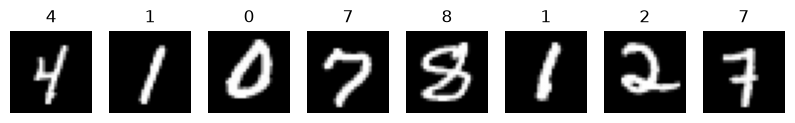

In [11]:
from tfdata_mlops.mnist_tfds import load_tfds_mnist

splits, source = load_tfds_mnist(cfg["part_d"]["data_dir"], batch_size=32)
images, labels = next(iter(splits["train"]))
print("route:", source, "| batch:", images.shape, images.dtype, "| labels:", labels.numpy()[:8])

fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, image, label in zip(axes, images[:8], labels[:8]):
    ax.imshow(image[..., 0], cmap="gray")
    ax.set_title(int(label))
    ax.axis("off")
plt.show()

## 6. Results of the full experiment

`reports/RESULTS.md` and the tables below are written by `python run_flow.py` (see the README); the figures are in `reports/figures`.

In [12]:
tables = ROOT / "reports" / "tables"
if (tables / "feature_summary.csv").exists():
    summary = pd.read_csv(tables / "feature_summary.csv")
    display(summary[["head", "feature_set", "features", "test_rmse", "test_rmse_lo", "test_rmse_hi", "test_r2"]].round(3))
else:
    print("Run `python run_flow.py --config configs/full_flow_config.yaml` to create the tables.")

,head,feature_set,features,test_rmse,test_rmse_lo,test_rmse_hi,test_r2
0,linear,numeric only,8,68473.347,68436.289,68510.405,0.640
1,linear,+ ocean one-hot,14,67489.588,67324.783,67654.392,0.651
2,linear,+ ocean embedding,10,67462.478,67373.095,67551.861,0.651
3,linear,+ income buckets,19,66603.592,66519.327,66687.858,0.660
4,linear,+ age x ocean,18,67149.033,67100.242,67197.824,0.654
5,linear,+ grid one-hot (400),414,62545.842,62414.089,62677.595,0.700
6,linear,+ grid embedding (400),22,62786.940,62643.776,62930.103,0.698
7,linear,+ hashed grid (1000),22,62845.618,62697.076,62994.160,0.697
8,linear,all features,31,61316.422,61234.124,61398.720,0.712
9,mlp,numeric only,8,51852.106,51314.325,52389.888,0.794
